# Unsupervised Machine Learning: PCA on MNIST

This notebook introduces **Principal Component Analysis (PCA)** using the MNIST handwritten digits dataset.

We will:

1. Download MNIST directly inside the notebook.
2. Visualize raw images as 784-dimensional vectors.
3. Show that boundary white pixels carry almost no information.
4. Fit PCA with scikit-learn.
5. Visualize how PCA creates new axes from the data.
6. Compare different `n_components` settings.
7. Reconstruct digits after dimensionality reduction.
8. Visualize PCA components as images.

The intuition: PCA rotates the coordinate system so that the first new axes capture the strongest variation in the dataset.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (8, 5)

## 1. Download MNIST

`fetch_openml('mnist_784')` downloads the classic MNIST dataset from OpenML.

Each image has shape **28 × 28**, flattened into **784 pixel features**.

In [4]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X = mnist.data.astype(np.float32)
y = mnist.target.astype(int)

# Scale pixel values from [0, 255] to [0, 1]
X = X / 255.0

print("X shape:", X.shape)
print("y shape:", y.shape)
print("One image is represented by", X.shape[1], "features")

X shape: (70000, 784)
y shape: (70000,)
One image is represented by 784 features


## 2. Visualize sample digits

The data is stored as vectors, but we can reshape each vector back into a 28 × 28 image.

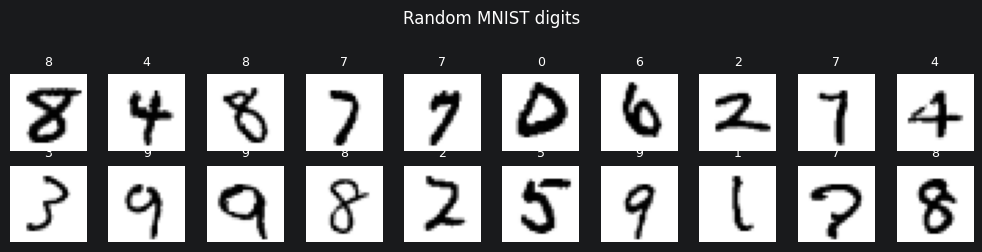

In [5]:
def plot_digits(images, labels=None, n=20, image_shape=(28, 28), title=None):
    cols = 10
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols, rows * 1.2))
    axes = np.array(axes).ravel()
    for i, ax in enumerate(axes):
        ax.axis('off')
        if i < n:
            ax.imshow(images[i].reshape(image_shape), cmap='gray_r')
            if labels is not None:
                ax.set_title(str(labels[i]), fontsize=9)
    if title:
        fig.suptitle(title, y=1.03)
    plt.tight_layout()

sample_idx = np.random.choice(len(X), size=20, replace=False)
plot_digits(X[sample_idx], y[sample_idx], n=20, title="Random MNIST digits")

## 3. Boundary white pixels store nearly no value

MNIST digits are centered. Pixels near the image boundary are usually white/background.

A simple way to prove this is to calculate the **average value** and **variance** of each pixel across all images.

Low variance means: this pixel is almost always the same, so it is not very useful for distinguishing digits.

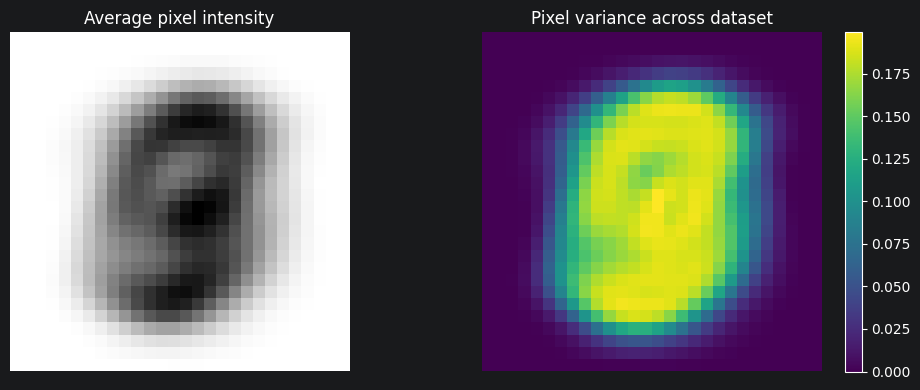

In [6]:
pixel_mean = X.mean(axis=0).reshape(28, 28)
pixel_variance = X.var(axis=0).reshape(28, 28)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(pixel_mean, cmap='gray_r')
axes[0].set_title('Average pixel intensity')
axes[0].axis('off')

im = axes[1].imshow(pixel_variance, cmap='viridis')
axes[1].set_title('Pixel variance across dataset')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout()

The variance map should show that the central area contains most of the useful signal, while the outer border is almost always background.

Now we measure how much variance is stored in each row and column.

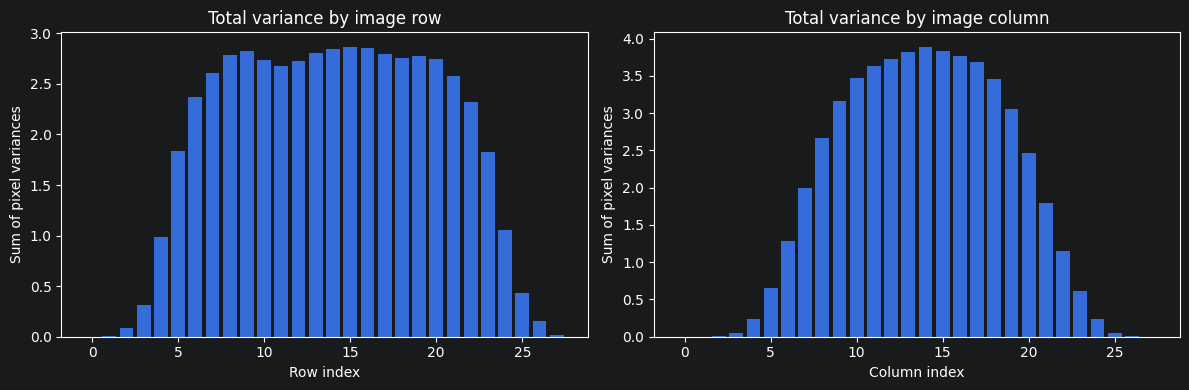

In [7]:
row_variance = pixel_variance.sum(axis=1)
col_variance = pixel_variance.sum(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(np.arange(28), row_variance)
axes[0].set_title('Total variance by image row')
axes[0].set_xlabel('Row index')
axes[0].set_ylabel('Sum of pixel variances')

axes[1].bar(np.arange(28), col_variance)
axes[1].set_title('Total variance by image column')
axes[1].set_xlabel('Column index')
axes[1].set_ylabel('Sum of pixel variances')
plt.tight_layout()

## 4. Remove almost empty boundary pixels

We can remove rows and columns whose variance is very small. This reduces dimensionality before PCA and removes features that carry almost no information.

This is not mandatory for PCA, but it is a useful teaching example: **not all input dimensions are equally informative**.

Rows kept: [ 2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26]
Columns kept: [ 3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
Original image shape: 28 x 28 = 784 features
Cropped image shape: 25 x 23 = 575 features


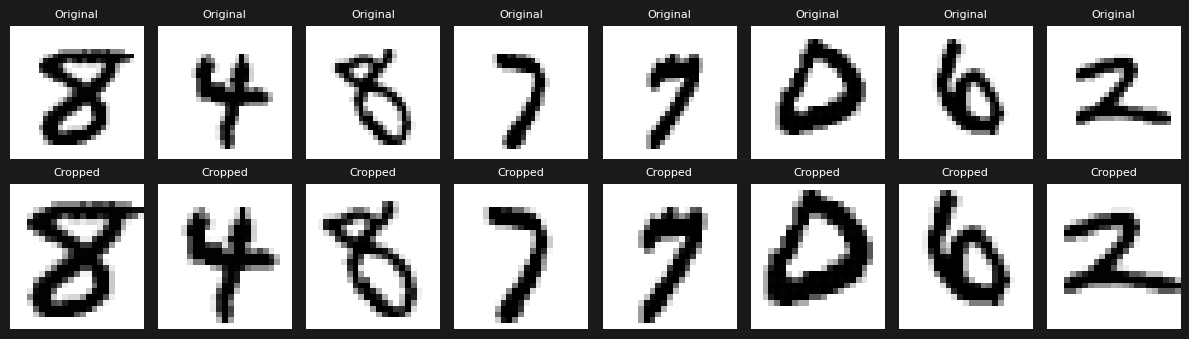

In [8]:
# Keep rows/columns that contain at least a small amount of variance.
# The threshold is intentionally simple and visual-friendly.
row_threshold = 0.01 * row_variance.max()
col_threshold = 0.01 * col_variance.max()

rows_to_keep = np.where(row_variance > row_threshold)[0]
cols_to_keep = np.where(col_variance > col_threshold)[0]

print("Rows kept:", rows_to_keep)
print("Columns kept:", cols_to_keep)
print("Original image shape: 28 x 28 =", 28 * 28, "features")
print("Cropped image shape:", len(rows_to_keep), "x", len(cols_to_keep), "=", len(rows_to_keep) * len(cols_to_keep), "features")

def crop_mnist_vectors(X_vectors, rows, cols):
    X_images = X_vectors.reshape(-1, 28, 28)
    X_cropped = X_images[:, rows][:, :, cols]
    return X_cropped.reshape(len(X_vectors), -1), X_cropped.shape[1:]

X_cropped, cropped_shape = crop_mnist_vectors(X, rows_to_keep, cols_to_keep)

fig, axes = plt.subplots(2, 8, figsize=(12, 3.5))
for i in range(8):
    axes[0, i].imshow(X[sample_idx[i]].reshape(28, 28), cmap='gray_r')
    axes[0, i].axis('off')
    axes[0, i].set_title('Original', fontsize=8)
    axes[1, i].imshow(X_cropped[sample_idx[i]].reshape(cropped_shape), cmap='gray_r')
    axes[1, i].axis('off')
    axes[1, i].set_title('Cropped', fontsize=8)
plt.tight_layout()

## 5. Fit PCA

PCA works best when features are centered. We will standardize the cropped pixel features before PCA.

For visualization and speed, we use a subset of the dataset.

In [9]:
# Use a subset to keep the notebook fast and responsive
subset_size = 10000
subset_idx = np.random.choice(len(X_cropped), size=subset_size, replace=False)
X_sub = X_cropped[subset_idx]
y_sub = y[subset_idx]

scaler = StandardScaler()
X_sub_scaled = scaler.fit_transform(X_sub)

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_sub_scaled)

print("Original cropped feature count:", X_sub_scaled.shape[1])
print("Reduced feature count:", X_pca_2d.shape[1])
print("Explained variance ratio:", pca_2d.explained_variance_ratio_)
print("Total explained variance:", pca_2d.explained_variance_ratio_.sum())

Original cropped feature count: 575
Reduced feature count: 2
Explained variance ratio: [0.0711519  0.05029845]
Total explained variance: 0.12145035


## 6. PCA as a new coordinate system

Originally, every image is described by pixel axes:

\[
X = [pixel_1, pixel_2, \dots, pixel_{784}]
\]

PCA creates new axes:

\[
Z = [PC_1, PC_2, \dots]
\]

The first principal component `PC1` captures the direction of maximum variance. The second component `PC2` captures the next strongest direction, orthogonal to `PC1`.

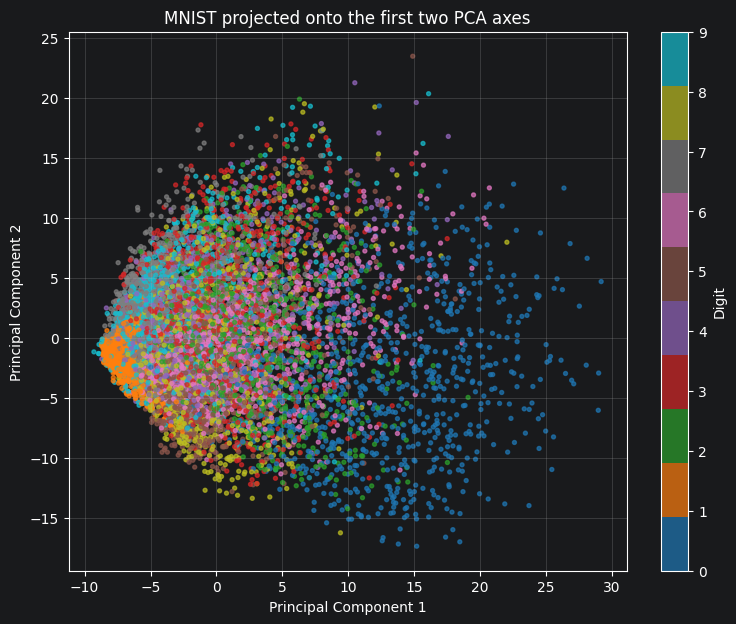

In [10]:
plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y_sub, s=8, alpha=0.7, cmap='tab10')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('MNIST projected onto the first two PCA axes')
plt.colorbar(scatter, label='Digit')
plt.grid(alpha=0.3)
plt.show()

## 7. Visualize PCA axes as images

Each PCA component is a vector in pixel space. We can reshape it back into an image.

Bright and dark regions show which pixels contribute strongly to a given principal component.

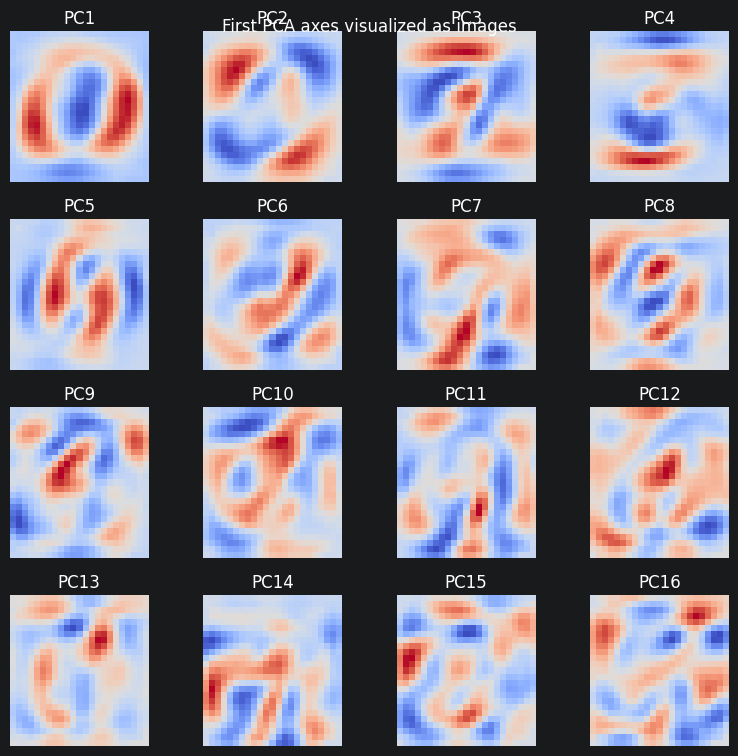

In [11]:
pca_many = PCA(n_components=16, random_state=RANDOM_STATE)
pca_many.fit(X_sub_scaled)

components_as_images = pca_many.components_.reshape(-1, *cropped_shape)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.ravel()):
    im = ax.imshow(components_as_images[i], cmap='coolwarm')
    ax.set_title(f'PC{i+1}')
    ax.axis('off')
plt.suptitle('First PCA axes visualized as images', y=0.93)
plt.tight_layout()

## 8. How `n_components` changes retained information

The parameter `n_components` controls how many new PCA axes we keep.

Keeping more components means:

- more information retained,
- better reconstruction,
- but less compression.

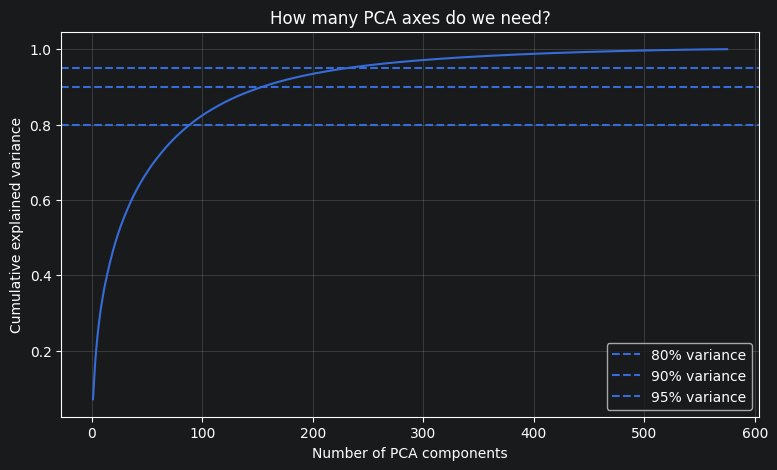

Components needed for 80% explained variance: 89
Components needed for 90% explained variance: 155
Components needed for 95% explained variance: 232


In [12]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_sub_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(9, 5))
plt.plot(np.arange(1, len(cumulative_variance) + 1), cumulative_variance)
plt.axhline(0.80, linestyle='--', label='80% variance')
plt.axhline(0.90, linestyle='--', label='90% variance')
plt.axhline(0.95, linestyle='--', label='95% variance')
plt.xlabel('Number of PCA components')
plt.ylabel('Cumulative explained variance')
plt.title('How many PCA axes do we need?')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

for target in [0.80, 0.90, 0.95]:
    n_needed = np.argmax(cumulative_variance >= target) + 1
    print(f"Components needed for {target:.0%} explained variance: {n_needed}")

## 9. Reconstruction after dimensionality reduction

PCA can compress data and then reconstruct an approximation of the original image.

The reconstruction is calculated by projecting data back from PCA space to the original pixel space.

In [13]:
def reconstruct_with_pca(X_scaled, n_components):
    pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
    Z = pca.fit_transform(X_scaled)
    X_reconstructed_scaled = pca.inverse_transform(Z)
    X_reconstructed = scaler.inverse_transform(X_reconstructed_scaled)
    X_reconstructed = np.clip(X_reconstructed, 0, 1)
    return X_reconstructed, pca.explained_variance_ratio_.sum()

example_count = 10
examples = X_sub_scaled[:example_count]
original_examples = X_sub[:example_count]

component_options = [5, 20, 50, 100]
reconstructions = []
for n_comp in component_options:
    reconstructed, variance_kept = reconstruct_with_pca(X_sub_scaled, n_comp)
    reconstructions.append((n_comp, variance_kept, reconstructed[:example_count]))

fig, axes = plt.subplots(len(component_options) + 1, example_count, figsize=(14, 7))

for i in range(example_count):
    axes[0, i].imshow(original_examples[i].reshape(cropped_shape), cmap='gray_r')
    axes[0, i].axis('off')
    axes[0, i].set_title('Original', fontsize=8)

for row_idx, (n_comp, variance_kept, reconstructed) in enumerate(reconstructions, start=1):
    for i in range(example_count):
        axes[row_idx, i].imshow(reconstructed[i].reshape(cropped_shape), cmap='gray_r')
        axes[row_idx, i].axis('off')
        if i == 0:
            axes[row_idx, i].set_ylabel(f'{n_comp} PCs
{variance_kept:.1%}', fontsize=9)

plt.suptitle('Digit reconstruction with different numbers of PCA components', y=0.98)
plt.tight_layout()

SyntaxError: unterminated f-string literal (detected at line 31) (3809233633.py, line 31)

## 10. Comparing PCA on original vs cropped images

Removing almost-empty boundary pixels reduces the number of input features before PCA.

This usually has little negative effect because those pixels contain very low variance.

In [ ]:
# Use the same subset indices for fair comparison
X_original_sub = X[subset_idx]
X_original_scaled = StandardScaler().fit_transform(X_original_sub)
X_cropped_scaled = StandardScaler().fit_transform(X_cropped[subset_idx])

pca_original = PCA(random_state=RANDOM_STATE).fit(X_original_scaled)
pca_cropped = PCA(random_state=RANDOM_STATE).fit(X_cropped_scaled)

cum_original = np.cumsum(pca_original.explained_variance_ratio_)
cum_cropped = np.cumsum(pca_cropped.explained_variance_ratio_)

plt.figure(figsize=(9, 5))
plt.plot(cum_original, label=f'Original: {X_original_scaled.shape[1]} features')
plt.plot(cum_cropped, label=f'Cropped: {X_cropped_scaled.shape[1]} features')
plt.xlabel('Number of PCA components')
plt.ylabel('Cumulative explained variance')
plt.title('Original vs cropped MNIST before PCA')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Summary

PCA is an unsupervised dimensionality reduction method.

Key ideas:

- Original pixel axes are not always the most useful coordinate system.
- PCA creates new axes ordered by variance.
- The first PCA axes preserve the strongest patterns in the data.
- Boundary pixels in MNIST have low variance and can often be removed.
- `n_components` controls the trade-off between compression and information loss.